В этом файле тестируем разные модели для выбора лучшей

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT=Path.cwd().parent
data_path=PROJECT_ROOT / 'data' / 'cars.csv'
artifacts_path=PROJECT_ROOT / 'artifacts'
configs_path=PROJECT_ROOT / 'configs'

RANDOM_STATE = 42

# Я ничего не придумал лучше, чем скопировать обработку сырых данных из файла с EDA
def prepare_raw_data(df):
    
    df=df.drop_duplicates()
    
    df=df.drop(['ID'],axis=1)
    
    df['Price']=df['Price']*73
    
    df['Manufacturer']=df['Manufacturer'].str.lower()
    
    manufacturer_counts = df['Manufacturer'].value_counts()
    rare_manufacturers = manufacturer_counts[manufacturer_counts < 15].index
    df['Manufacturer'] = df['Manufacturer'].replace(rare_manufacturers, 'other')

    df['Model']=df['Model'].str.lower()
    model_counts = df['Model'].value_counts()
    rare_models = model_counts[model_counts < 10].index
    df['Model'] = df['Model'].replace(rare_models, 'other')
    
    df.loc[df['Fuel type'] == 'Plug-in Hybrid', 'Fuel type'] = 'hybrid'
    df.loc[(df['Fuel type'] == 'CNG') | (df['Fuel type'] == 'LPG'), 'Fuel type'] = 'gas'
    df['Fuel type']=df['Fuel type'].str.lower()

    df['Engine volume']=df['Engine volume'].str.replace(" Turbo","")
    df['Engine volume']=df['Engine volume'].astype(float)

    df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

    df['Drive wheels']=df['Drive wheels'].str.lower()

    df.loc[df['Doors'] == '04-May', 'Doors'] = '4'
    df.loc[df['Doors'] == '02-Mar', 'Doors'] = '2'

    df.loc[df['Wheel'] == 'Left wheel', 'Wheel'] = 'left'
    df.loc[df['Wheel'] == 'Right-hand drive', 'Wheel'] = 'right'

    df['Color']=df['Color'].str.lower()

    df = df[(df['Price'] > 50000) & (df['Price'] < df['Price'].quantile(0.98))]
    df = df[(df['Prod. year'] >= 1970) & (df['Prod. year'] <= 2026)]
    df = df[df['Mileage'] >= 0]
    df = df[df['Engine volume'] > 0 & (df['Engine volume'] < df['Engine volume'].quantile(0.98))]
    df = df[(df['Cylinders'] > 0) & (df['Cylinders'] < 16)]

    df=df[df['Mileage']<1000000]

    return df

df = pd.read_csv(data_path)
df = prepare_raw_data(df)

Формируем данные

In [2]:
from sklearn.model_selection import train_test_split

num_features = ['Prod. year','Engine volume','Mileage','Cylinders','Airbags']
cat_features = ['Manufacturer','Model','Category','Leather interior','Fuel type','Gear box type','Drive wheels','Doors','Wheel','Color']

X = df[num_features + cat_features]
y = np.log(df['Price'])      # логарифм цены – целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Создаём препроцессор

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

preprocessor.fit(X_train)

# Преобразуем данные
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Функции, нужные для рассчёта метрик(RMSE, MAE, MSE) и подбора гиперпараметров

In [4]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

# KFold для кросс-валидации
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []           # список метрик для каждой модели
best_models = {}       # обученная модель
search_summaries = {}  # best_params, best_cv_score

def compute_metrics(y_true, y_pred):
    """Расчёт метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse)
    }

def print_metrics(y_true, y_pred, title=None):
    """Вывод метрик"""
    if title:
        print(f"\n{title}")
        print("=" * len(title))
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"MAE  = {mae:.4f}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    """Оценка модели на тестовых данных"""
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)
    metrics["model"] = label
    return metrics

def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def run_search(label, estimator, param_grid, X_train, y_train, X_test, y_test, scoring="neg_mean_squared_error"):
    """Поиск гиперпараметров с GridSearchCV"""
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )
    search.fit(X_train, y_train)
    
    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
        "scoring": scoring
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

Baseline модель(DummyRegressor)

In [5]:
from sklearn.dummy import DummyRegressor

dummy_mean = DummyRegressor(strategy="mean")
dummy_mean.fit(X_train_processed, y_train)
print_metrics(y_test, dummy_mean.predict(X_test_processed), title="Dummy (mean)")
results.append(evaluate_on_test(dummy_mean, X_test_processed, y_test, "Dummy_Mean"))


Dummy (mean)
MAE  = 0.7395
MSE  = 0.9358
RMSE = 0.9674


Random Forest Regressor с небольшим поиском гиперпараметров

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Базовый RF
rf_base = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_processed, y_train)
print_metrics(y_test, rf_base.predict(X_test_processed), title="RandomForest (base: n_estimators=100)")

# Поиск лучших параметров
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = run_search(
    "RandomForest", rf, rf_grid,
    X_train_processed, y_train, X_test_processed, y_test,
    scoring="neg_mean_squared_error"
)

print("\n" + "="*40)
print("ЛУЧШИЕ ПАРАМЕТРЫ RANDOMFOREST")
print("="*40)
print(f"Best params: {search_summaries['RandomForest']['best_params']}")
print(f"Best CV neg MSE: {search_summaries['RandomForest']['best_cv_score']:.4f}")
print(f"Соответствует RMSE: {np.sqrt(-search_summaries['RandomForest']['best_cv_score']):.4f}")

best_rf = best_models['RandomForest']
print_metrics(y_test, best_rf.predict(X_test_processed), title="RandomForest (tuned) – Test")


RandomForest (base: n_estimators=100)
MAE  = 0.2658
MSE  = 0.2137
RMSE = 0.4622
Fitting 5 folds for each of 24 candidates, totalling 120 fits

ЛУЧШИЕ ПАРАМЕТРЫ RANDOMFOREST
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV neg MSE: -0.2376
Соответствует RMSE: 0.4874

RandomForest (tuned) – Test
MAE  = 0.2658
MSE  = 0.2128
RMSE = 0.4613


XGBoost Regressor с небольшим поиском гиперпараметров

In [7]:
import xgboost as xgb

# Базовый XGBoost
xgb_base = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                             random_state=RANDOM_STATE, n_jobs=-1)
xgb_base.fit(X_train_processed, y_train)
print_metrics(y_test, xgb_base.predict(X_test_processed), title="XGBoost (base)")

# Поиск параметров
xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = run_search(
    "XGBoost", xgb_model, xgb_grid,
    X_train_processed, y_train, X_test_processed, y_test,
    scoring="neg_mean_squared_error"
)

print("\n" + "="*40)
print("ЛУЧШИЕ ПАРАМЕТРЫ XGBOOST")
print("="*40)
print(f"Best params: {search_summaries['XGBoost']['best_params']}")
print(f"Best CV neg MSE: {search_summaries['XGBoost']['best_cv_score']:.4f}")
print(f"Соответствует RMSE: {np.sqrt(-search_summaries['XGBoost']['best_cv_score']):.4f}")

best_xgb = best_models['XGBoost']
print_metrics(y_test, best_xgb.predict(X_test_processed), title="XGBoost (tuned) – Test")


XGBoost (base)
MAE  = 0.4471
MSE  = 0.4159
RMSE = 0.6449
Fitting 5 folds for each of 32 candidates, totalling 160 fits

ЛУЧШИЕ ПАРАМЕТРЫ XGBOOST
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV neg MSE: -0.2948
Соответствует RMSE: 0.5429

XGBoost (tuned) – Test
MAE  = 0.3590
MSE  = 0.2864
RMSE = 0.5352


Сортируем результаты тестов по RMSE

In [8]:
# Собираем результаты всех моделей в DataFrame
df_results = pd.DataFrame(results)

# Сортируем по RMSE (чем меньше, тем лучше) и сбрасываем индекс
df_sorted = df_results.sort_values("rmse", ascending=True).reset_index(drop=True)

df_sorted = df_results.sort_values("rmse", ascending=True).reset_index(drop=True)

print("\n" + "="*40)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*40)
print(df_sorted[["model", "mae", "rmse"]].to_string(index=True))


СРАВНЕНИЕ МОДЕЛЕЙ
          model       mae      rmse
0  RandomForest  0.265759  0.461271
1       XGBoost  0.359049  0.535207
2    Dummy_Mean  0.739480  0.967354


Графики тестов по RMSE и MAE

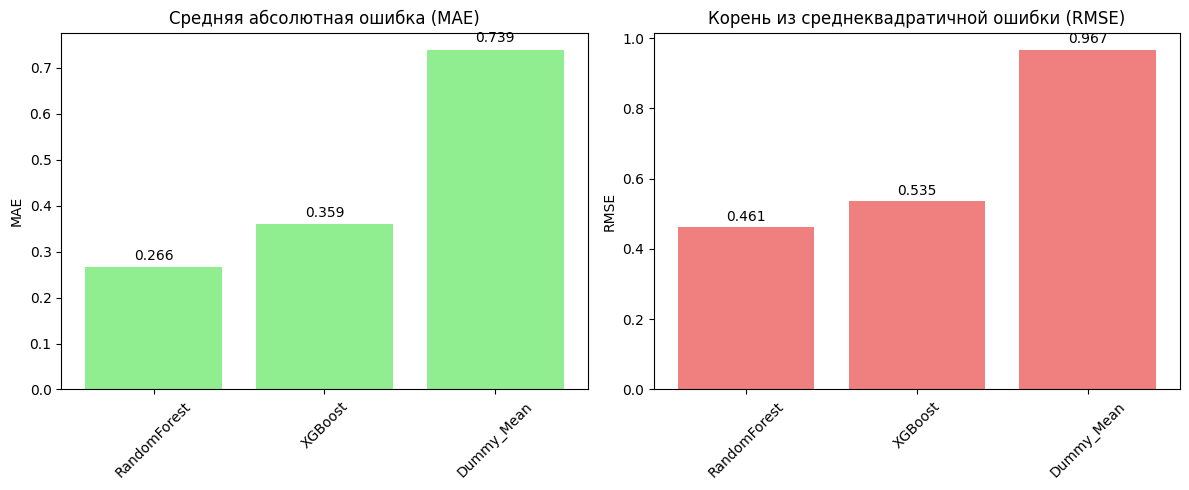

In [9]:
import matplotlib.pyplot as plt

# График сравнения MAE и RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE
ax = axes[0]
models = df_sorted["model"]
mae_vals = df_sorted["mae"]
bars = ax.bar(models, mae_vals, color='lightgreen')
ax.set_ylabel("MAE")
ax.set_title("Средняя абсолютная ошибка (MAE)")
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

# RMSE
ax = axes[1]
rmse_vals = df_sorted["rmse"]
bars = ax.bar(models, rmse_vals, color='lightcoral')
ax.set_ylabel("RMSE")
ax.set_title("Корень из среднеквадратичной ошибки (RMSE)")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(artifacts_path / "model_comparison.png")
plt.show()

In [10]:
# Лучшая модель
best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

print(f"ЛУЧШАЯ МОДЕЛЬ: {best_label}")
print(f"RMSE = {best_row['rmse']:.4f}")
print(f"MAE  = {best_row['mae']:.4f}")

ЛУЧШАЯ МОДЕЛЬ: RandomForest
RMSE = 0.4613
MAE  = 0.2658


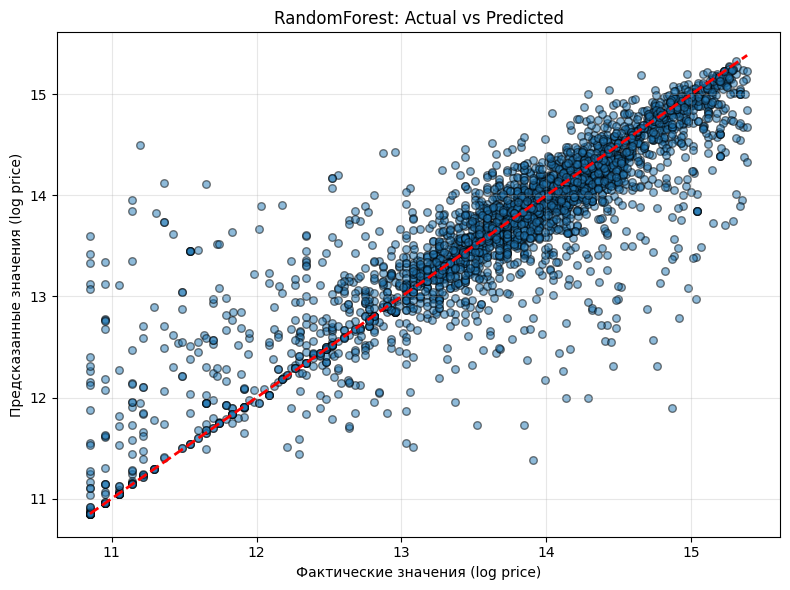

In [11]:
# Предсказания лучшей модели
y_pred_best = best_model.predict(X_test_processed)

# График actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Фактические значения (log price)")
plt.ylabel("Предсказанные значения (log price)")
plt.title(f"{best_label}: Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(artifacts_path / f"{best_label}_actual_vs_pred.png")
plt.show()

In [12]:
import json

# Сохраняем результаты тестов
save_json(df_sorted.to_dict(orient="records"), artifacts_path / "metrics_test.json")
save_json(search_summaries, artifacts_path / "search_summaries_test.json")

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "best_params": search_summaries[best_label]["best_params"],
    "random_state": RANDOM_STATE
}
save_json(meta, configs_path / "best_model_meta_test.json")